# 09 · Acesso à Energia Elétrica — 03_VISUALIZACAO
Amazonas (AM) · Censo 2010 · lê `energia-am.geojson` (gerado pelo `01_ETL.ipynb`)

**Visualizações**
1. Mapa coroplético: % sem energia por município
2. Gráfico de barras: top 15 municípios com maior exclusão
3. Scatter: distância a Manaus × % sem energia
4. Mapa de bolhas: população × % sem energia por município
5. Comparativo rural × urbano: gráfico agrupado por mesorregião

**Saídas:** PNGs em `figuras/` (dentro da pasta de saída, no Drive se estiver no Colab).

> Usa só `matplotlib`, `numpy`, `pandas` e `scipy`: os polígonos são desenhados direto do GeoJSON (em lon/lat), então não depende do GeoPandas. Os números são recalculados a partir das contagens do `energia-am.geojson`, portanto este notebook roda mesmo sem o `02_ANALISE`.

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch, Patch
from matplotlib.collections import PatchCollection
from matplotlib.ticker import FuncFormatter
from scipy import stats

try:                                            # Google Colab: usa a mesma pasta do 01 e do 02
    from google.colab import drive
    drive.mount("/content/drive")
    DIR_SAIDA = Path("/content/drive/MyDrive/saida")
except ImportError:                             # fora do Colab: pasta local
    DIR_SAIDA = Path("saida")

ARQ_ENERGIA = DIR_SAIDA / "energia-am.geojson"
DIR_FIG = DIR_SAIDA / "figuras"
DIR_FIG.mkdir(parents=True, exist_ok=True)

COD_MANAUS = 1302603
TOP_N = 15
DPI = 200
CMAP = "YlOrRd"
FONTE = "Fonte: IBGE, Censo Demográfico 2010 (Resultados do Universo, por setor censitário); elaboração própria."
COR_RURAL, COR_URBANA = "#B5451B", "#3A6EA5"

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "axes.titlesize": 13, "axes.titleweight": "bold"})

def br(v, d=1):
    """Número no formato brasileiro (vírgula decimal)."""
    return f"{v:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def salvar(fig, nome):
    fig.savefig(DIR_FIG / nome, dpi=DPI, bbox_inches="tight", facecolor="white")
    print("salvo:", DIR_FIG / nome)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Leitura e verificação

In [5]:
with open(ARQ_ENERGIA, encoding="utf-8") as f:
    gj = json.load(f)
feats = gj["features"]
df = pd.DataFrame([ft["properties"] for ft in feats])
df["geom"] = [ft["geometry"] for ft in feats]

numericas = ["cd_mun", "dom_total", "dom_sem", "pct_sem", "dom_total_rural", "dom_sem_rural", "pct_sem_rural",
             "dom_total_urbana", "dom_sem_urbana", "pct_sem_urbana", "pop_dpp", "dist_manaus_km"]
faltam = [c for c in numericas + ["nm_mun", "nm_meso"] if c not in df.columns]
assert not faltam, f"Colunas ausentes em {ARQ_ENERGIA.name}: {faltam}. Rode o 01_ETL novamente."
df[numericas] = df[numericas].apply(pd.to_numeric, errors="coerce")
assert len(df) == 62 and df["cd_mun"].is_unique, "Esperados 62 municípios únicos"

# ---- Geometria (GeoJSON em lon/lat) ----
def _poligonos(geom):
    return geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]

def caminho(geom):
    """Converte a geometria em um Path do matplotlib (com buracos)."""
    verts, codes = [], []
    for poly in _poligonos(geom):
        for anel in poly:
            r = np.asarray(anel)[:, :2]
            verts.extend(r)
            codes.extend([MPath.MOVETO] + [MPath.LINETO] * (len(r) - 2) + [MPath.CLOSEPOLY])
    return MPath(np.array(verts), codes)

def centroide(geom):
    """Centroide (lon, lat) da maior parte do polígono, por área."""
    melhor = None
    for poly in _poligonos(geom):
        x, y = np.asarray(poly[0])[:, :2].T
        cruz = x[:-1] * y[1:] - x[1:] * y[:-1]
        a = 0.5 * cruz.sum()
        if a == 0:
            continue
        cx = ((x[:-1] + x[1:]) * cruz).sum() / (6 * a)
        cy = ((y[:-1] + y[1:]) * cruz).sum() / (6 * a)
        if melhor is None or abs(a) > melhor[0]:
            melhor = (abs(a), cx, cy)
    return melhor[1], melhor[2]

df["cx"], df["cy"] = zip(*df["geom"].map(centroide))
todos = np.vstack([caminho(g).vertices for g in df["geom"]])
XMIN, YMIN = todos.min(axis=0); XMAX, YMAX = todos.max(axis=0)
assert -75 < XMIN < XMAX < -55 and -11 < YMIN < YMAX < 3, \
    "Coordenadas fora do AM: o arquivo deve estar em EPSG:4326 (rode o 01_ETL atualizado)."

def poligonos_mun(**kw):
    return PatchCollection([PathPatch(caminho(g)) for g in df["geom"]], **kw)

def formatar_mapa(ax):
    ax.set_xlim(XMIN - 0.3, XMAX + 0.3); ax.set_ylim(YMIN - 0.3, YMAX + 0.3)
    ax.set_aspect(1 / np.cos(np.radians((YMIN + YMAX) / 2)))       # correção de escala lon/lat
    ax.axis("off")

# ---- Totais do estado (somando contagens, não médias de percentuais) ----
pct_estado = 100 * df["dom_sem"].sum() / df["dom_total"].sum()
meso_curto = df["nm_meso"].str.replace(" Amazonense", "", regex=False)
ordem_meso = sorted(meso_curto.unique())
COR_MESO = dict(zip(ordem_meso, ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]))
df["meso"] = meso_curto
print(f"{len(df)} municípios | {br(pct_estado)}% dos domicílios do estado sem energia | mesorregiões: {ordem_meso}")

62 municípios | 6,6% dos domicílios do estado sem energia | mesorregiões: ['Centro', 'Norte', 'Sudoeste', 'Sul']


## 1. Mapa coroplético — % de domicílios sem energia por município
Escala contínua a partir de 0. Os cinco municípios com maior percentual estão rotulados.

salvo: /content/drive/MyDrive/saida/figuras/01_mapa_coropletico.png


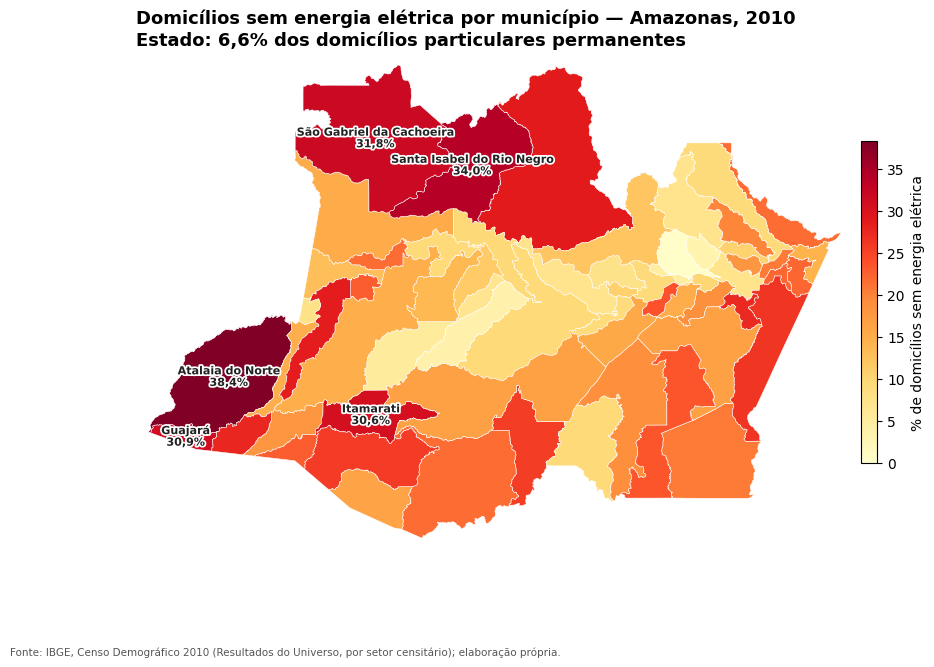

In [6]:
fig, ax = plt.subplots(figsize=(11, 7.6))
pc = poligonos_mun(cmap=CMAP, edgecolor="white", linewidth=0.4)
pc.set_array(df["pct_sem"].to_numpy()); pc.set_clim(0, df["pct_sem"].max())
ax.add_collection(pc)
formatar_mapa(ax)

cb = fig.colorbar(pc, ax=ax, shrink=0.55, pad=0.01)
cb.set_label("% de domicílios sem energia elétrica")

for _, r in df.nlargest(5, "pct_sem").iterrows():
    ax.annotate(f"{r['nm_mun']}\n{br(r['pct_sem'])}%", (r["cx"], r["cy"]), ha="center", va="center",
                fontsize=8, fontweight="bold", color="#222",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax.set_title(f"Domicílios sem energia elétrica por município — Amazonas, 2010\n"
             f"Estado: {br(pct_estado)}% dos domicílios particulares permanentes", loc="left")
fig.text(0.01, 0.03, FONTE, fontsize=7.5, color="#555")
salvar(fig, "01_mapa_coropletico.png"); plt.show()

## 2. Top 15 municípios com maior exclusão energética
Barras coloridas por mesorregião; a linha tracejada é o percentual do estado. O `n` é o total de domicílios: percentuais de municípios pequenos oscilam mais.

salvo: /content/drive/MyDrive/saida/figuras/02_top15_municipios.png


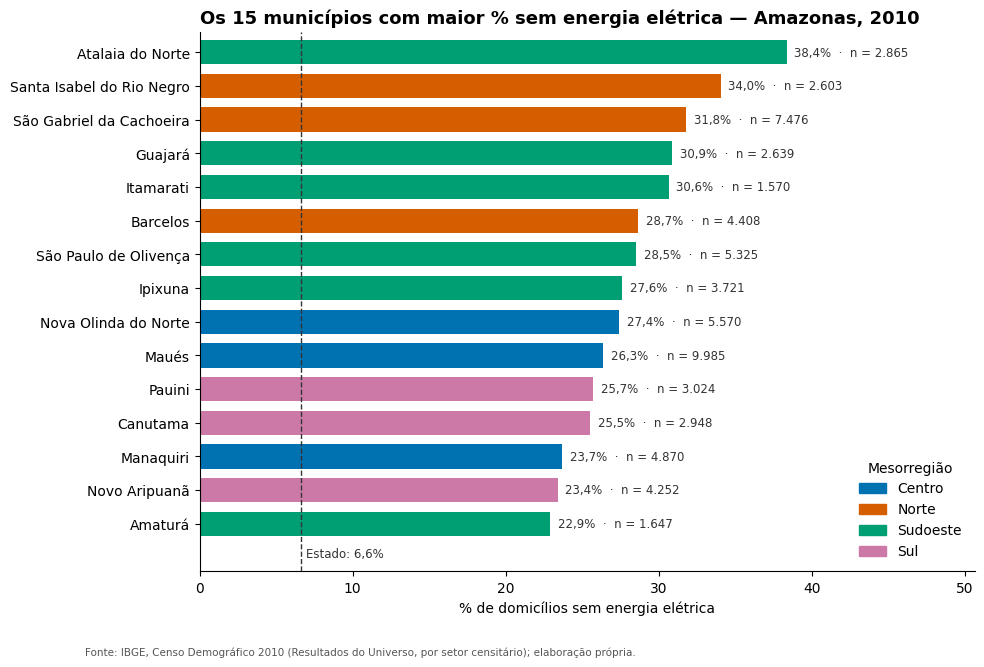

In [7]:
top = df.nlargest(TOP_N, "pct_sem").sort_values("pct_sem")          # menor embaixo, maior em cima
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top["nm_mun"], top["pct_sem"], color=[COR_MESO[m] for m in top["meso"]], height=0.72)

for y, (_, r) in enumerate(top.iterrows()):
    ax.text(r["pct_sem"] + 0.5, y, f"{br(r['pct_sem'])}%  ·  n = {br(r['dom_total'], 0)}",
            va="center", fontsize=8.5, color="#333")

ax.axvline(pct_estado, color="#333", linestyle="--", linewidth=1)
ax.text(pct_estado + 0.3, -0.9, f"Estado: {br(pct_estado)}%", fontsize=8.5, color="#333", va="center")
ax.set_xlim(0, top["pct_sem"].max() * 1.32)
ax.set_xlabel("% de domicílios sem energia elétrica")
ax.set_ylim(-1.4, len(top) - 0.4)
ax.legend(handles=[Patch(color=COR_MESO[m], label=m) for m in ordem_meso if m in set(top["meso"])],
          title="Mesorregião", loc="lower right", frameon=False)
ax.set_title(f"Os {TOP_N} municípios com maior % sem energia elétrica — Amazonas, 2010", loc="left")
fig.text(0.01, -0.01, FONTE, fontsize=7.5, color="#555")
salvar(fig, "02_top15_municipios.png"); plt.show()

## 3. Distância a Manaus × % sem energia
Cada ponto é um município (área proporcional ao nº de domicílios). Painel esquerdo: % total; direito: só a zona rural. O ρ de Spearman é calculado **sem Manaus** (distância 0, capital). A distância é em linha reta, não fluvial.

salvo: /content/drive/MyDrive/saida/figuras/03_scatter_distancia.png


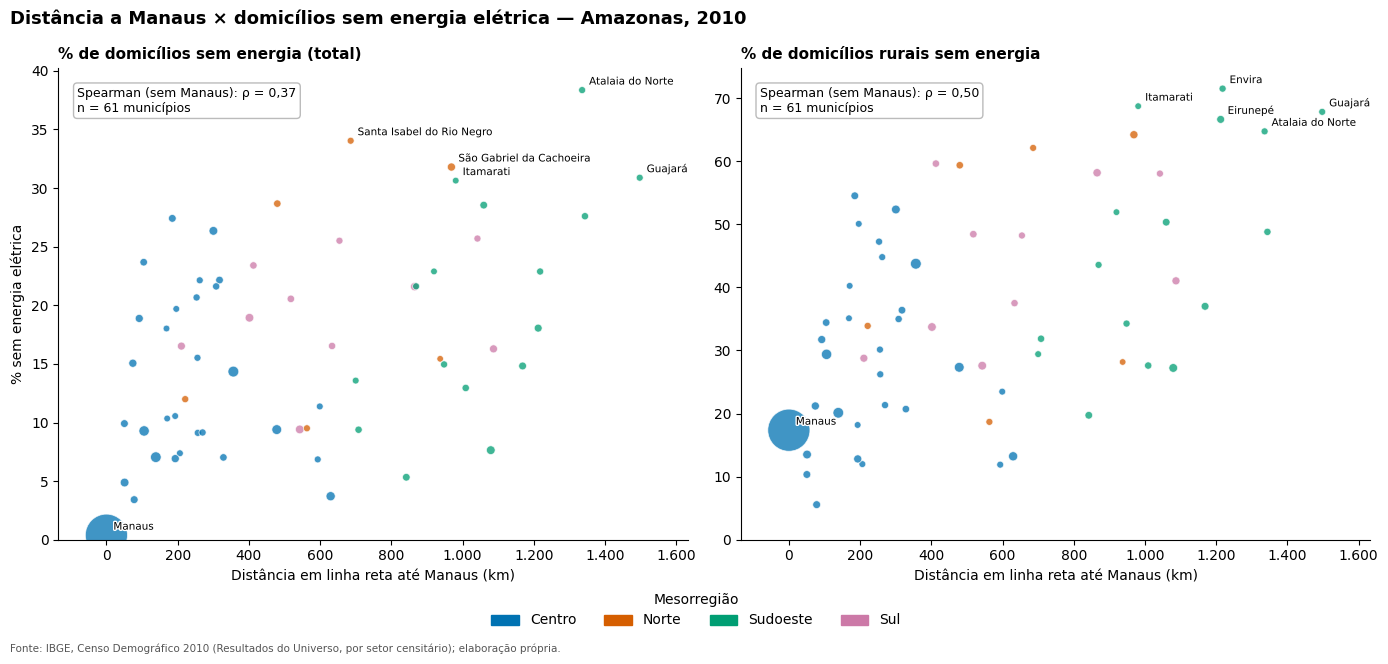

In [8]:
def painel(ax, ycol, titulo, rotulos=5):
    d = df.dropna(subset=[ycol])
    cor = [COR_MESO[m] for m in d["meso"]]
    ax.scatter(d["dist_manaus_km"], d[ycol], s=20 + 900 * d["dom_total"] / d["dom_total"].max(),
               c=cor, alpha=0.75, edgecolor="white", linewidth=0.6)
    dd = d[d["cd_mun"] != COD_MANAUS]
    rho, p = stats.spearmanr(dd["dist_manaus_km"], dd[ycol])
    ax.text(0.03, 0.96, f"Spearman (sem Manaus): ρ = {br(rho, 2)}\nn = {len(dd)} municípios",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="#bbb"))
    for _, r in pd.concat([d.nlargest(rotulos, ycol), d[d["cd_mun"] == COD_MANAUS]]).drop_duplicates("cd_mun").iterrows():
        ax.annotate(r["nm_mun"], (r["dist_manaus_km"], r[ycol]), xytext=(5, 4), textcoords="offset points",
                    fontsize=7.5, path_effects=[pe.withStroke(linewidth=2, foreground="white")])
    ax.set_xlabel("Distância em linha reta até Manaus (km)")
    ax.set_title(titulo, loc="left", fontsize=11)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: br(v, 0)))
    ax.set_ylim(bottom=0); ax.margins(x=0.09)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
painel(a1, "pct_sem", "% de domicílios sem energia (total)")
painel(a2, "pct_sem_rural", "% de domicílios rurais sem energia")
a1.set_ylabel("% sem energia elétrica")
fig.legend(handles=[Patch(color=COR_MESO[m], label=m) for m in ordem_meso], title="Mesorregião",
           loc="lower center", ncol=len(ordem_meso), frameon=False, bbox_to_anchor=(0.5, -0.07))
fig.suptitle("Distância a Manaus × domicílios sem energia elétrica — Amazonas, 2010", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
fig.text(0.01, -0.09, FONTE, fontsize=7.5, color="#555")
fig.tight_layout()
salvar(fig, "03_scatter_distancia.png"); plt.show()

## 4. Mapa de bolhas — população × % sem energia
A **área** da bolha cresce com a população (moradores em domicílios particulares permanentes) e a **cor** indica o % sem energia. Como Manaus tem ~1,8 milhão de moradores e a maioria dos municípios menos de 30 mil, a escala é comprimida (área ∝ população^0,75, ajustável em `EXP`); leia os tamanhos da legenda, não a proporção literal. A bolha fica no centro do município.

salvo: /content/drive/MyDrive/saida/figuras/04_mapa_bolhas.png


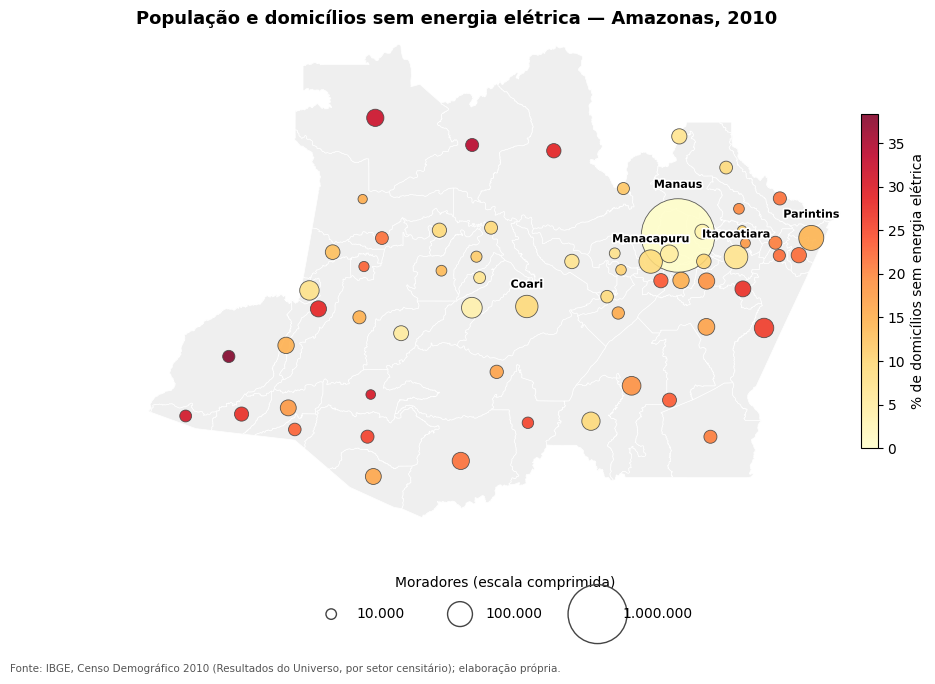

In [9]:
EXP = 0.75                                               # área ∝ população^0,75 (escala comprimida)
SC = 2800 / df["pop_dpp"].max() ** EXP                   # bolha de Manaus ≈ 2.800 pt²
tam = lambda pop: SC * np.asarray(pop, dtype=float) ** EXP

fig, ax = plt.subplots(figsize=(11, 7.9))
ax.add_collection(poligonos_mun(facecolor="#EFEFEF", edgecolor="white", linewidth=0.5))
formatar_mapa(ax)

d = df.sort_values("pop_dpp", ascending=False)         # bolhas grandes atrás, pequenas na frente
sc = ax.scatter(d["cx"], d["cy"], s=tam(d["pop_dpp"]), c=d["pct_sem"], cmap=CMAP,
                vmin=0, vmax=d["pct_sem"].max(), edgecolor="#444", linewidth=0.6, alpha=0.88)
cb = fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.01)
cb.set_label("% de domicílios sem energia elétrica")

for _, r in df.nlargest(5, "pop_dpp").iterrows():
    raio = np.sqrt(tam(r["pop_dpp"]) / np.pi)
    ax.annotate(r["nm_mun"], (r["cx"], r["cy"]), xytext=(0, raio + 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

refs = [10_000, 100_000, 1_000_000]
handles = [ax.scatter([], [], s=tam(v), facecolor="none", edgecolor="#444") for v in refs]
fig.legend(handles, [br(v, 0) for v in refs], title="Moradores (escala comprimida)", loc="lower center",
           ncol=3, frameon=False, labelspacing=1.2, columnspacing=3, borderpad=1.2, bbox_to_anchor=(0.46, 0.035))

ax.set_title("População e domicílios sem energia elétrica — Amazonas, 2010", loc="left")
fig.text(0.01, 0.0, FONTE, fontsize=7.5, color="#555")
salvar(fig, "04_mapa_bolhas.png"); plt.show()

## 5. Comparativo rural × urbano por mesorregião
Percentuais calculados sobre as **contagens somadas** de cada mesorregião. A divisão em mesorregiões é a de 2010, a mesma do Censo utilizado.

salvo: /content/drive/MyDrive/saida/figuras/05_rural_urbano_mesorregiao.png


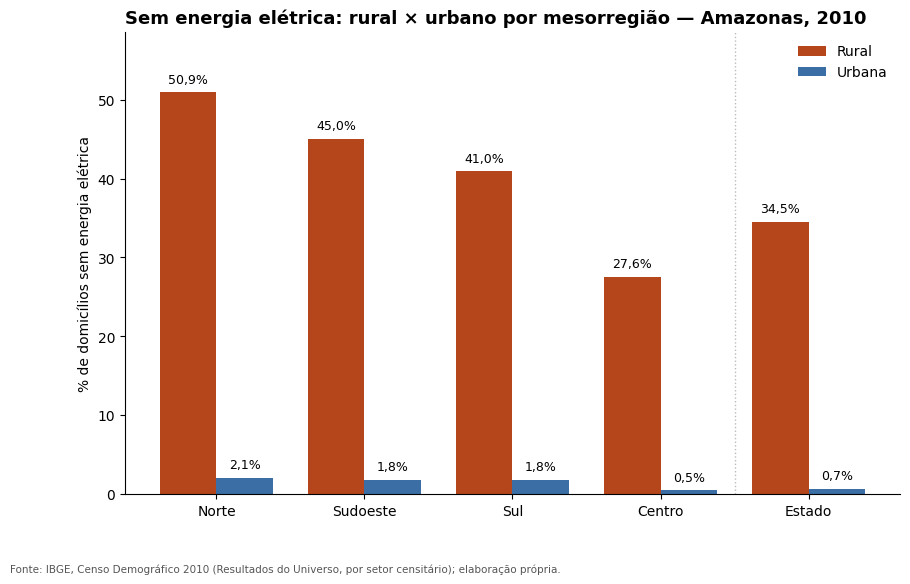

,Rural,Urbana
meso,,
Norte,50.94,2.08
Sudoeste,45.04,1.83
Sul,40.96,1.83
Centro,27.56,0.49
Estado,34.53,0.68


In [10]:
cols = ["dom_total_rural", "dom_sem_rural", "dom_total_urbana", "dom_sem_urbana"]
g = df.groupby("meso")[cols].sum()
g.loc["Estado"] = df[cols].sum()
g["Rural"]  = 100 * g["dom_sem_rural"]  / g["dom_total_rural"]
g["Urbana"] = 100 * g["dom_sem_urbana"] / g["dom_total_urbana"]
g = g.loc[g.drop("Estado").sort_values("Rural", ascending=False).index.tolist() + ["Estado"]]

x = np.arange(len(g)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - w / 2, g["Rural"],  w, color=COR_RURAL,  label="Rural")
b2 = ax.bar(x + w / 2, g["Urbana"], w, color=COR_URBANA, label="Urbana")
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f"{br(b.get_height())}%",
                ha="center", va="bottom", fontsize=9)
ax.axvline(len(g) - 1.5, color="#bbb", linewidth=1, linestyle=":")
ax.set_xticks(x); ax.set_xticklabels(g.index)
ax.set_ylabel("% de domicílios sem energia elétrica")
ax.set_ylim(0, g["Rural"].max() * 1.15)
ax.legend(frameon=False, loc="upper right")
ax.set_title("Sem energia elétrica: rural × urbano por mesorregião — Amazonas, 2010", loc="left")
fig.text(0.01, -0.02, FONTE, fontsize=7.5, color="#555")
salvar(fig, "05_rural_urbano_mesorregiao.png"); plt.show()
g[["Rural", "Urbana"]].round(2)

## Como usar estas figuras
- Cite sempre o ano (**2010**): a Luz para Todos e a expansão de sistemas isolados mudaram o quadro depois disso.
- Os setores com menos de 5 domicílios são omitidos pelo IBGE (ver `01_ETL`), então os percentuais dos menores municípios têm mais incerteza.
- No scatter, a distância é em linha reta; no AM o acesso real é fluvial.
- Correlação entre municípios não permite concluir nada sobre domicílios individuais.